In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
from datetime import datetime
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
us_data = pd.read_csv('/content/drive/Shared drives/CS 163 - Group 9/fao.csv')
birds = pd.read_csv('/content/drive/Shared drives/CS 163 - Group 9/Affected_Birds.csv')

In [4]:
us_data[us_data['Product']=='Chicken'].tail()

,Country,Product,Price (Latest date),Latest date,Food Group
1378,United States,Chicken,12.27,2026-01-04,Protein
1379,United States,Chicken,12.26,2026-01-11,Protein
1380,United States,Chicken,12.25,2026-01-18,Protein
1381,United States,Chicken,12.25,2026-01-25,Protein
1382,United States,Chicken,12.25,2026-02-01,Protein


In [5]:
#Clean birds dataset
birds["Confirmed"] = pd.to_datetime(birds["Confirmed"], errors="coerce")
birds = birds[['Confirmed', 'Birds Affected']]
birds['Birds Affected'] = birds['Birds Affected'].replace({',': ''}, regex=True).astype(int)
birds = birds[birds['Confirmed'] <= us_data['Latest date'].max()]
birds = birds.sort_values(by=['Confirmed'], ascending=True).reset_index(drop=True)

/tmp/ipykernel_11912/3861535348.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  birds["Confirmed"] = pd.to_datetime(birds["Confirmed"], errors="coerce")


In [6]:
birds.head()

,Confirmed,Birds Affected
0,2022-02-08,29000
1,2022-02-12,231400
2,2022-02-12,90
3,2022-02-15,53300
4,2022-02-16,26600


In [7]:
#Chicken and egg
chicken = us_data[us_data['Product'] == 'Chicken']
chicken['Latest date'] = pd.to_datetime(chicken['Latest date'], errors='coerce')

egg = us_data[us_data['Product'] == 'Chicken Egg']
egg['Latest date'] = pd.to_datetime(egg['Latest date'], errors='coerce')

/tmp/ipykernel_11912/3690682359.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chicken['Latest date'] = pd.to_datetime(chicken['Latest date'], errors='coerce')
/tmp/ipykernel_11912/3690682359.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  egg['Latest date'] = pd.to_datetime(egg['Latest date'], errors='coerce')


#Chicken

In [8]:
#Find unique dates in chicken
chicken_date = chicken[chicken['Latest date'] >= birds['Confirmed'].min()]
chicken_points = chicken_date[chicken_date['Product'] == 'Chicken']['Latest date'].unique() #min = 2022-03-06, max = 2026-02-01

In [9]:
#Group by date
birdsc = birds.groupby(['Confirmed'])['Birds Affected'].sum().reset_index()
temp = pd.DataFrame({
    'Confirmed': chicken_points,
    'Birds Affected': [0 for x in chicken_points]
})
birdsc = pd.concat([birdsc, temp]).sort_values(by=['Confirmed'], ascending=True).reset_index(drop=True)

In [10]:
#Sum affected birds by chicken date
align_chicken = pd.DataFrame(columns=['Date', 'Birds Affected'])
time_idx = 0
affected_sum = 0
for i in range(len(birdsc)):
  curr_time = birdsc.loc[i, 'Confirmed']
  if curr_time == chicken_points[time_idx]:
    align_chicken.loc[len(align_chicken)] = [chicken_points[time_idx], affected_sum]
    affected_sum = 0
    time_idx += 1
  else:
    affected_sum += birdsc.loc[i, 'Birds Affected']

In [11]:
#Log Affected
align_chicken['Log Affected'] = np.log(align_chicken['Birds Affected'] + 1)

#Percent Change
affected_pct_change = []
for i in range(len(align_chicken)):
  if i == 0:
      affected_pct_change.append(0)
  else:
    pct_change = round((align_chicken.loc[i, 'Birds Affected'] - align_chicken.loc[i-1, 'Birds Affected']) / align_chicken.loc[i-1, 'Birds Affected'], 2)
    affected_pct_change.append(pct_change)
align_chicken['Percent Change'] = affected_pct_change

align_chicken

/tmp/ipykernel_11912/1027784828.py:10: RuntimeWarning: invalid value encountered in scalar divide
  pct_change = round((align_chicken.loc[i, 'Birds Affected'] - align_chicken.loc[i-1, 'Birds Affected']) / align_chicken.loc[i-1, 'Birds Affected'], 2)
/tmp/ipykernel_11912/1027784828.py:10: RuntimeWarning: divide by zero encountered in scalar divide
  pct_change = round((align_chicken.loc[i, 'Birds Affected'] - align_chicken.loc[i-1, 'Birds Affected']) / align_chicken.loc[i-1, 'Birds Affected'], 2)


,Date,Birds Affected,Log Affected,Percent Change
0,2022-03-06,2486978,14.726579,0.00
1,2022-03-13,2113000,14.563620,-0.15
2,2022-03-20,8621696,15.969792,3.08
3,2022-03-27,2132100,14.572618,-0.75
4,2022-04-10,9395595,16.055752,3.41
...,...,...,...,...
156,2026-01-04,376564,12.838846,4.56
157,2026-01-11,431300,12.974562,0.15
158,2026-01-18,607410,13.316961,0.41
159,2026-01-25,31890,10.370079,-0.95


In [12]:
#Price Change
price_change = []
for i in range(len(chicken)):
  if i == 0:
    price_change.append(0)
  else:
    change = chicken.iloc[i]['Price (Latest date)'] - chicken.iloc[i-1]['Price (Latest date)']
    price_change.append(change)

chicken['Price Change'] = price_change

/tmp/ipykernel_11912/3349766653.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chicken['Price Change'] = price_change


In [13]:
#Rename Columns, Merge, Drop uncessary columns
chicken.rename(columns={'Latest date': 'Date', 'Price (Latest date)': 'Price'}, inplace=True)
chicken_final = pd.merge(align_chicken, chicken, how='inner')
chicken_final

/tmp/ipykernel_11912/254236000.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chicken.rename(columns={'Latest date': 'Date', 'Price (Latest date)': 'Price'}, inplace=True)


,Date,Birds Affected,Log Affected,Percent Change,Country,Product,Price,Food Group,Price Change
0,2022-03-06,2486978,14.726579,0.00,United States,Chicken,9.46,Protein,0.08
1,2022-03-13,2113000,14.563620,-0.15,United States,Chicken,9.48,Protein,0.02
2,2022-03-20,8621696,15.969792,3.08,United States,Chicken,9.49,Protein,0.01
3,2022-03-27,2132100,14.572618,-0.75,United States,Chicken,9.50,Protein,0.01
4,2022-04-10,9395595,16.055752,3.41,United States,Chicken,9.46,Protein,-0.04
...,...,...,...,...,...,...,...,...,...
156,2026-01-04,376564,12.838846,4.56,United States,Chicken,12.27,Protein,-0.01
157,2026-01-11,431300,12.974562,0.15,United States,Chicken,12.26,Protein,-0.01
158,2026-01-18,607410,13.316961,0.41,United States,Chicken,12.25,Protein,-0.01
159,2026-01-25,31890,10.370079,-0.95,United States,Chicken,12.25,Protein,0.00


In [14]:
#Form static theshold for severity using quantiles
chicken_final['Birds Affected'].describe()

#Rounded to integer
very_low = 20580
low = 292435
medium = 2117775

In [15]:
#Severity Column
def get_severity(x):
  if x <= very_low:
    return 0 #very low
  elif x <= low:
    return 1 #low
  elif x <= medium:
    return 2 #medium
  else:
    return 3 #high

chicken_final['Severity'] = chicken_final['Birds Affected'].apply(get_severity)

In [16]:
#Days Between and Lag features
chicken_final['Days Between'] = chicken_final['Date'].diff().dt.days
chicken_final['Price Lag'] = chicken_final['Price'].shift(1)
chicken_final['Price Diff Lag'] = chicken_final['Price Change'].shift(1)
chicken_final['Affected Lag'] = chicken_final['Birds Affected'].shift(1)
chicken_final['Severity Lag'] = chicken_final['Severity'].shift(1)
chicken_final['Severity Lag 2'] = chicken_final['Severity'].shift(2)

In [17]:
#Drop infinity and nan
chicken_final = chicken_final.replace([np.inf, -np.inf], np.nan)
chicken_final = chicken_final.dropna().reset_index(drop=True)

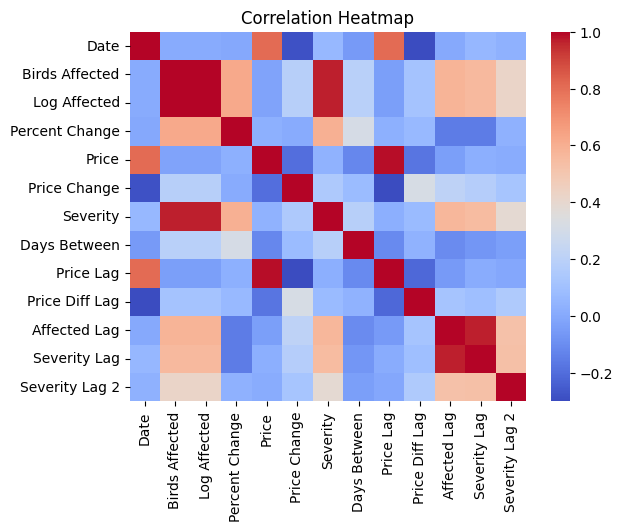

In [18]:
chicken_corr = chicken_final.drop(columns=['Country', 'Product', 'Food Group'])
pearson_corr = chicken_corr.corr(method='spearman')
sns.heatmap(pearson_corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [19]:
#Model
X = chicken_final[[
    'Birds Affected',
    'Log Affected',
    'Percent Change',
    'Days Between',
    'Price Lag',
    'Price Diff Lag',
    'Affected Lag',
    'Severity',
    'Severity Lag',
    'Severity Lag 2'
]]
y = chicken_final['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)

chicken_model = RandomForestRegressor(
    n_estimators = 200,
    max_depth = 10,
    min_samples_leaf = 3,
    random_state = 42
)
chicken_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=3, n_estimators=200,
                      random_state=42)

In [20]:
#Model Metrics
y_pred = np.round(chicken_model.predict(X_test), 2)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('MAE:', mae)
print('RMSE:', rmse)
print('R2:', r2)

tolerance = 0.05 #5 cents
within_tol = np.abs(y_pred - y_test) <= tolerance
tol_acc = np.sum(within_tol == True) / len(within_tol)

print('Within Tolerance Accuracy:', round(tol_acc, 3))
#More tuning needed but decent for now

MAE: 0.024074074074073692
RMSE: 0.0009222222222221975
R2: 0.12756293797042362
Within Tolerance Accuracy: 0.963


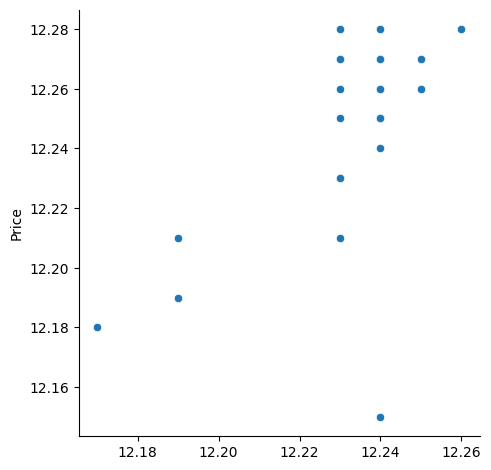

In [21]:
sns.relplot(x=y_pred, y=y_test)

In [22]:
#Model results preview
chicken_test_data = X_test
chicken_test_data['Price Predicted'] = y_pred
chicken_test_data['Price Actual'] = y_test
chicken_test_data.head()

,Birds Affected,Log Affected,Percent Change,Days Between,Price Lag,Price Diff Lag,Affected Lag,Severity,Severity Lag,Severity Lag 2,Price Predicted,Price Actual
108,638754,13.367276,0.73,14.0,12.17,0.01,368279.0,2,2.0,0.0,12.17,12.18
109,597,6.393591,-1.00,7.0,12.18,0.01,638754.0,0,2.0,2.0,12.19,12.19
110,5196750,15.463544,8703.77,21.0,12.19,0.01,597.0,3,0.0,2.0,12.19,12.21
111,342100,12.742861,-0.93,7.0,12.21,0.02,5196750.0,2,3.0,0.0,12.23,12.21
112,50,3.931826,-1.00,14.0,12.21,0.00,342100.0,0,2.0,3.0,12.23,12.23


In [23]:
#Price prediction interval
price_interval = pd.DataFrame(columns=['Severity', 'Price Diff'])
price_interval['Severity'] = chicken_test_data['Severity']
price_interval['Price Diff'] = chicken_test_data['Price Predicted'] - chicken_test_data['Price Actual']
price_interval.groupby(['Severity'])['Price Diff'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Severity,,,,,,,,
0,4.0,0.02,0.04,0.00,0.00,0.00,0.02,0.09
1,6.0,-0.03,0.01,-0.04,-0.04,-0.03,-0.02,-0.01
2,13.0,-0.02,0.02,-0.05,-0.03,-0.02,-0.01,0.02
3,4.0,-0.02,0.00,-0.02,-0.02,-0.02,-0.02,-0.02


In [24]:
#Feature importance
importances = chicken_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

print(feat_imp)

Price Lag         0.985512
Affected Lag      0.004848
Severity Lag      0.002530
Birds Affected    0.001831
Log Affected      0.001760
Price Diff Lag    0.001484
Percent Change    0.001035
Severity Lag 2    0.000494
Severity          0.000489
Days Between      0.000018
dtype: float64


#Egg

In [25]:
#Find unique dates in egg
egg_date = egg[egg['Latest date'] >= birds['Confirmed'].min()]
egg_points = egg_date[egg_date['Product'] == 'Chicken Egg']['Latest date'].unique()

In [26]:
#Group by date
birdse = birds.groupby(['Confirmed'])['Birds Affected'].sum().reset_index()
temp = pd.DataFrame({
    'Confirmed': egg_points,
    'Birds Affected': [0 for x in egg_points]
})
birdse = pd.concat([birdse, temp]).sort_values(by=['Confirmed'], ascending=True).reset_index(drop=True)
birdse = birdse[birdse['Confirmed'] <= egg_points.max()]

In [27]:
#Sum affected birds by egg date
align_egg = pd.DataFrame(columns=['Date', 'Birds Affected'])
time_idx = 0
affected_sum = 0
for i in range(len(birdse)):
  curr_time = birdse.loc[i, 'Confirmed']
  if curr_time == egg_points[time_idx]:
    align_egg.loc[len(align_egg)] = [egg_points[time_idx], affected_sum]
    affected_sum = 0
    time_idx += 1
  else:
    affected_sum += birdse.loc[i, 'Birds Affected']

In [28]:
#Log Affected
align_egg['Log Affected'] = np.log(align_egg['Birds Affected'] + 1)

#Percent Change
affected_pct_change = []
for i in range(len(align_egg)):
  if i == 0:
      affected_pct_change.append(0)
  else:
    pct_change = round((align_egg.loc[i, 'Birds Affected'] - align_egg.loc[i-1, 'Birds Affected']) / align_egg.loc[i-1, 'Birds Affected'], 2)
    affected_pct_change.append(pct_change)
align_egg['Percent Change'] = affected_pct_change

/tmp/ipykernel_11912/1707400893.py:10: RuntimeWarning: invalid value encountered in scalar divide
  pct_change = round((align_egg.loc[i, 'Birds Affected'] - align_egg.loc[i-1, 'Birds Affected']) / align_egg.loc[i-1, 'Birds Affected'], 2)
/tmp/ipykernel_11912/1707400893.py:10: RuntimeWarning: divide by zero encountered in scalar divide
  pct_change = round((align_egg.loc[i, 'Birds Affected'] - align_egg.loc[i-1, 'Birds Affected']) / align_egg.loc[i-1, 'Birds Affected'], 2)


In [29]:
#Price Change
price_change = []
for i in range(len(egg)):
  if i == 0:
    price_change.append(0)
  else:
    change = egg.iloc[i]['Price (Latest date)'] - egg.iloc[i-1]['Price (Latest date)']
    price_change.append(change)

egg['Price Change'] = price_change

/tmp/ipykernel_11912/1541320576.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  egg['Price Change'] = price_change


In [30]:
#Rename Columns and Merge
egg.rename(columns={'Latest date': 'Date', 'Price (Latest date)': 'Price'}, inplace=True)
egg_final = pd.merge(align_egg, egg, how='inner')
egg_final

/tmp/ipykernel_11912/148838543.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  egg.rename(columns={'Latest date': 'Date', 'Price (Latest date)': 'Price'}, inplace=True)


,Date,Birds Affected,Log Affected,Percent Change,Country,Product,Price,Food Group,Price Change
0,2022-02-13,260490,12.470324,0.00,United States,Chicken Egg,2.32,Protein,0.00
1,2022-02-20,79938,11.289019,-0.69,United States,Chicken Egg,2.32,Protein,0.00
2,2022-03-06,2146550,14.579373,25.85,United States,Chicken Egg,2.32,Protein,0.00
3,2022-03-13,2113000,14.563620,-0.02,United States,Chicken Egg,2.32,Protein,0.00
4,2022-03-20,8621696,15.969792,3.08,United States,Chicken Egg,2.33,Protein,0.01
...,...,...,...,...,...,...,...,...,...
155,2025-08-31,55430,10.922894,38.59,United States,Chicken Egg,4.38,Protein,0.02
156,2025-09-07,139850,11.848333,1.52,United States,Chicken Egg,4.38,Protein,0.00
157,2025-09-21,375210,12.835244,1.68,United States,Chicken Egg,4.39,Protein,0.01
158,2025-10-12,6141731,15.630617,15.37,United States,Chicken Egg,4.40,Protein,0.01


In [31]:
#Form static theshold for severity using quantiles
print(egg_final['Birds Affected'].describe())

#Rounded to integer
very_low = 14234
low = 202789
medium = 2127614

count    1.600000e+02
mean     1.134818e+06
std      1.942527e+06
min      0.000000e+00
25%      3.465000e+02
50%      1.312500e+05
75%      1.834995e+06
max      1.166912e+07
Name: Birds Affected, dtype: float64


In [32]:
#Severity Column
def get_severity(x):
  if x <= very_low:
    return 0 #very low
  elif x <= low:
    return 1 #low
  elif x <= medium:
    return 2 #medium
  else:
    return 3 #high

egg_final['Severity'] = egg_final['Birds Affected'].apply(get_severity)

In [33]:
#Days Between and Lag features
egg_final['Days Between'] = egg_final['Date'].diff().dt.days
egg_final['Price Lag'] = egg_final['Price'].shift(1)
egg_final['Price Diff Lag'] = egg_final['Price Change'].shift(1)
egg_final['Affected Lag'] = egg_final['Birds Affected'].shift(1)
egg_final['Severity Lag'] = egg_final['Severity'].shift(1)
egg_final['Severity Lag 2'] = egg_final['Severity'].shift(2)

In [34]:
#Drop infinity and nan
egg_final = egg_final.replace([np.inf, -np.inf], np.nan)
egg_final = egg_final.dropna().reset_index(drop=True)

In [35]:
egg_final.head()

,Date,Birds Affected,Log Affected,Percent Change,Country,Product,Price,Food Group,Price Change,Severity,Days Between,Price Lag,Price Diff Lag,Affected Lag,Severity Lag,Severity Lag 2
0,2022-03-06,2146550,14.579373,25.85,United States,Chicken Egg,2.32,Protein,0.00,3,14.0,2.32,0.00,79938.0,1.0,2.0
1,2022-03-13,2113000,14.563620,-0.02,United States,Chicken Egg,2.32,Protein,0.00,2,7.0,2.32,0.00,2146550.0,3.0,1.0
2,2022-03-20,8621696,15.969792,3.08,United States,Chicken Egg,2.33,Protein,0.01,3,7.0,2.32,0.00,2113000.0,2.0,3.0
3,2022-03-27,2081690,14.548691,-0.76,United States,Chicken Egg,2.33,Protein,0.00,2,7.0,2.33,0.01,8621696.0,3.0,2.0
4,2022-04-03,7427711,15.820728,2.57,United States,Chicken Egg,2.33,Protein,0.00,3,7.0,2.33,0.00,2081690.0,2.0,3.0


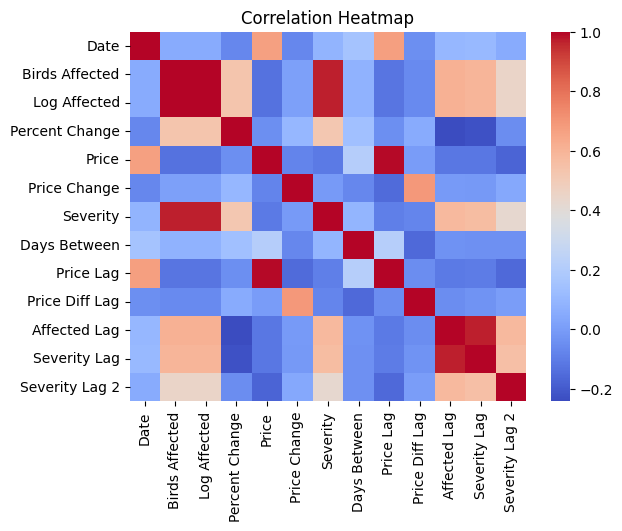

In [36]:
egg_corr = egg_final.drop(columns=['Country', 'Product', 'Food Group'])
pearson_corr = egg_corr.corr(method='spearman')
sns.heatmap(pearson_corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [37]:
#Model
X = egg_final[[
    'Birds Affected',
    'Log Affected',
    'Percent Change',
    'Days Between',
    'Price Change',
    'Price Lag',
    'Price Diff Lag',
    'Affected Lag',
    'Severity',
    'Severity Lag',
    'Severity Lag 2'
]]
y = egg_final['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)

egg_model = RandomForestRegressor(
    n_estimators = 200,
    max_depth = 10,
    min_samples_leaf = 3,
    random_state = 42
)
egg_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=3, n_estimators=200,
                      random_state=42)

In [38]:
#Model Metrics
y_pred = np.round(egg_model.predict(X_test), 2)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('MAE:', mae)
print('RMSE:', rmse)
print('R2:', r2)

tolerance = 0.05 #5 cents
within_tol = np.abs(y_pred - y_test) <= tolerance
tol_acc = np.sum(within_tol == True) / len(within_tol)

print('Within Tolerance Accuracy:', round(tol_acc, 3))
#More tuning needed but decent for now

MAE: 0.037777777777777875
RMSE: 0.0018518518518518604
R2: 0.9506449065543562
Within Tolerance Accuracy: 0.778


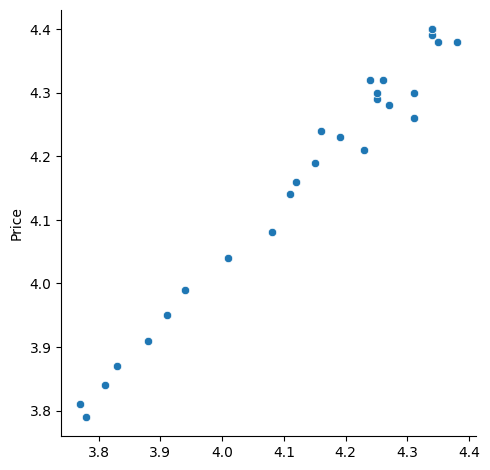

In [39]:
sns.relplot(x=y_pred, y=y_test)

In [40]:
egg_test_data = X_test
egg_test_data['Price Predicted'] = y_pred
egg_test_data['Price Actual'] = y_test
egg_test_data = egg_test_data.reset_index(drop=True)

In [41]:
price_interval = pd.DataFrame(columns=['Severity', 'Price Diff'])
price_interval['Severity'] = egg_test_data['Severity']
price_interval['Price Diff'] = egg_test_data['Price Predicted'] - egg_test_data['Price Actual']
price_interval.groupby(['Severity'])['Price Diff'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Severity,,,,,,,,
0,4.0,-0.04,0.04,-0.08,-0.07,-0.05,-0.03,0.01
1,6.0,-0.02,0.02,-0.04,-0.03,-0.02,-0.00,0.02
2,7.0,-0.03,0.04,-0.08,-0.06,-0.04,-0.01,0.05
3,10.0,-0.04,0.01,-0.06,-0.05,-0.04,-0.03,-0.01


In [42]:
# Percent interval by severity
pct_interval = pd.DataFrame()
pct_interval["Severity"] = egg_test_data["Severity"]
pct_interval["Pct Diff"] = (egg_test_data["Price Predicted"] - egg_test_data["Price Actual"]) / egg_test_data["Price Actual"] * 100

pct_interval.groupby("Severity")["Pct Diff"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Severity,,,,,,,,
0,4.0,-1.00,0.91,-1.89,-1.51,-1.17,-0.66,0.23
1,6.0,-0.36,0.54,-0.96,-0.73,-0.46,-0.06,0.48
2,7.0,-0.69,1.00,-1.85,-1.25,-0.95,-0.36,1.17
3,10.0,-0.96,0.31,-1.36,-1.13,-1.02,-0.82,-0.26


/tmp/ipykernel_11912/4176887030.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(pct_data, labels=sorted(pct_interval["Severity"].unique()))


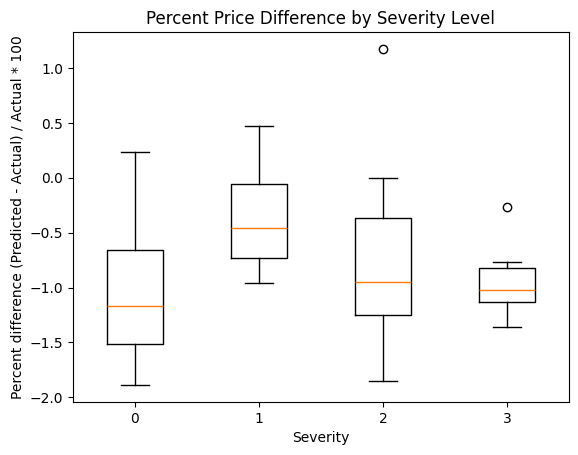

In [43]:
# percent differences by severity
plt.figure()
pct_data = [pct_interval[pct_interval["Severity"] == s]["Pct Diff"].dropna().values for s in sorted(pct_interval["Severity"].unique())]
plt.boxplot(pct_data, labels=sorted(pct_interval["Severity"].unique()))
plt.title("Percent Price Difference by Severity Level")
plt.xlabel("Severity")
plt.ylabel("Percent difference (Predicted - Actual) / Actual * 100")
plt.show()

In [44]:
#feature importance
importances = egg_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

print(feat_imp)

Price Lag         0.989960
Affected Lag      0.004094
Severity Lag 2    0.002410
Birds Affected    0.000996
Log Affected      0.000732
Price Diff Lag    0.000537
Severity Lag      0.000411
Price Change      0.000333
Percent Change    0.000278
Severity          0.000244
Days Between      0.000007
dtype: float64


In [45]:
#Predicted price change
predicted_price_change = [0]
for i in range(1, len(egg_test_data)):
  predicted_price_change.append(round(egg_test_data.loc[i, 'Price Predicted'] - egg_test_data.loc[i-1, 'Price Predicted'], 2))
egg_test_data['Predicted Price Change'] = predicted_price_change

In [46]:
egg_test_data.groupby(['Severity Lag 2'])['Predicted Price Change'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Severity Lag 2,,,,,,,,
0.0,5.0,0.01,0.04,-0.04,-0.04,0.03,0.04,0.05
1.0,6.0,0.01,0.04,-0.04,-0.02,0.00,0.02,0.08
2.0,6.0,0.03,0.06,-0.02,-0.01,0.00,0.02,0.15
3.0,10.0,0.03,0.03,-0.01,0.02,0.03,0.05,0.07
